In [1]:
!pip install anndata==0.8.0

In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import csv
import pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [26]:
fn = 'Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad'

In [27]:
sam = SAM()
sam.load_data(fn)

In [28]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3'],
      dtype='object')

In [29]:
org = 'DR'
level = 'ss_subclass_nounlabeled_nmm_cl_v4_nn'

In [30]:
sam.adata.obs[level].unique()

['339 Astrocyte-like NN', 'dr_9', '338 Lymphoid NN', '333 Endo NN', 'dr_5', ..., '130 LHA Pmch Glut', '041 OB-in Frmd7 Gaba', '314 CB Granule Glut', 'dr_37', '062 STR D2 Gaba']
Length: 61
Categories (61, object): ['041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', '049 Lamp5 Gaba', '054 STR Prox1 Lhx6 Gaba', ..., 'dr_31', 'dr_34', 'dr_35', 'dr_37']

In [31]:
sorted_list = np.sort(list(sam.adata.obs[level].unique()))
order_one = []
order_two = []
for item in sorted_list:
    if 'NN' in item or item == 'Unlabeled':
        order_two.append(item)
    else:
        order_one.append(item)

In [32]:
len(order_one)

47

In [33]:
len(order_two)

14

In [34]:
order_one

['041 OB-in Frmd7 Gaba',
 '045 OB-STR-CTX Inh IMN',
 '049 Lamp5 Gaba',
 '054 STR Prox1 Lhx6 Gaba',
 '056 Sst Chodl Gaba',
 '060 OT D3 Folh1 Gaba',
 '062 STR D2 Gaba',
 '075 MEA-BST Lhx6 Nr2e1 Gaba',
 '077 CEA-BST Gal Avp Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 '091 ARH-PVi Six6 Dopa-Gaba',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '105 TMd-DMH Foxd2 Gaba',
 '111 TRS-BAC Sln Glut',
 '123 DMH Nkx2-4 Glut',
 '130 LHA Pmch Glut',
 '131 LHA-AHN-PVH Otp Trh Glut',
 '133 PVH-SO-PVa Otp Glut',
 '145 MH Tac2 Glut',
 '314 CB Granule Glut',
 'ac_dr_1',
 'cj_ac_xt_dr_1',
 'cj_ac_xt_dr_3',
 'cj_ac_xt_dr_4',
 'cj_xt_dr_1',
 'cj_xt_dr_2',
 'dr_10',
 'dr_11',
 'dr_14',
 'dr_16',
 'dr_18',
 'dr_19',
 'dr_2',
 'dr_20',
 'dr_22',
 'dr_23',
 'dr_25',
 'dr_26',
 'dr_28',
 'dr_31',
 'dr_34',
 'dr_35',
 'dr_37',
 'dr_5',
 'dr_7',
 'dr_8',
 'dr_9']

In [35]:
#reset to the order you like
order_one = ['041 OB-in Frmd7 Gaba',
 '045 OB-STR-CTX Inh IMN',
 '049 Lamp5 Gaba',
 '054 STR Prox1 Lhx6 Gaba',
 '056 Sst Chodl Gaba',
 '060 OT D3 Folh1 Gaba',
 '062 STR D2 Gaba',
 '075 MEA-BST Lhx6 Nr2e1 Gaba',
 '077 CEA-BST Gal Avp Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 '091 ARH-PVi Six6 Dopa-Gaba',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '105 TMd-DMH Foxd2 Gaba',
 '111 TRS-BAC Sln Glut',
 '123 DMH Nkx2-4 Glut',
 '130 LHA Pmch Glut',
 '131 LHA-AHN-PVH Otp Trh Glut',
 '133 PVH-SO-PVa Otp Glut',
 '145 MH Tac2 Glut',
 '314 CB Granule Glut',
 'cj_xt_dr_2',
 'cj_ac_xt_dr_4',
 'ac_dr_1',
 'cj_xt_dr_1',
 'cj_ac_xt_dr_1',
 'cj_ac_xt_dr_3',
 'dr_10',
 'dr_11',
 'dr_14',
 'dr_16',
 'dr_18',
 'dr_19',
 'dr_2',
 'dr_20',
 'dr_22',
 'dr_23',
 'dr_25',
 'dr_26',
 'dr_28',
 'dr_31',
 'dr_34',
 'dr_35',
 'dr_37',
 'dr_5',
 'dr_7',
 'dr_8',
 'dr_9']

In [36]:
with open("Figures/Figures_07242026/"+org+"_order.csv", "w", newline="") as f:
    writer = csv.writer(f)
    for item in order_one:
        writer.writerow([item])
    for item in order_two:
        writer.writerow([item])

In [37]:
# split order_one into tiles of at most chunk_size cell types
chunk_size = 60
order_one_chunks = [order_one[i:i + chunk_size] for i in range(0, len(order_one), chunk_size)]

# width of a full (chunk_size wide) tile, in inches; partial tiles are scaled so
# the violins/bars stay the same width across all tiles
tile_width = 40

[len(c) for c in order_one_chunks]

[47]

In [38]:
if len(order_two) > 0:
    frac = chunk_size/len(order_two)

In [39]:
sam.adata.obs['n_counts'].quantile(.999)

21323.284000000014

In [40]:
ncount_max = 22000

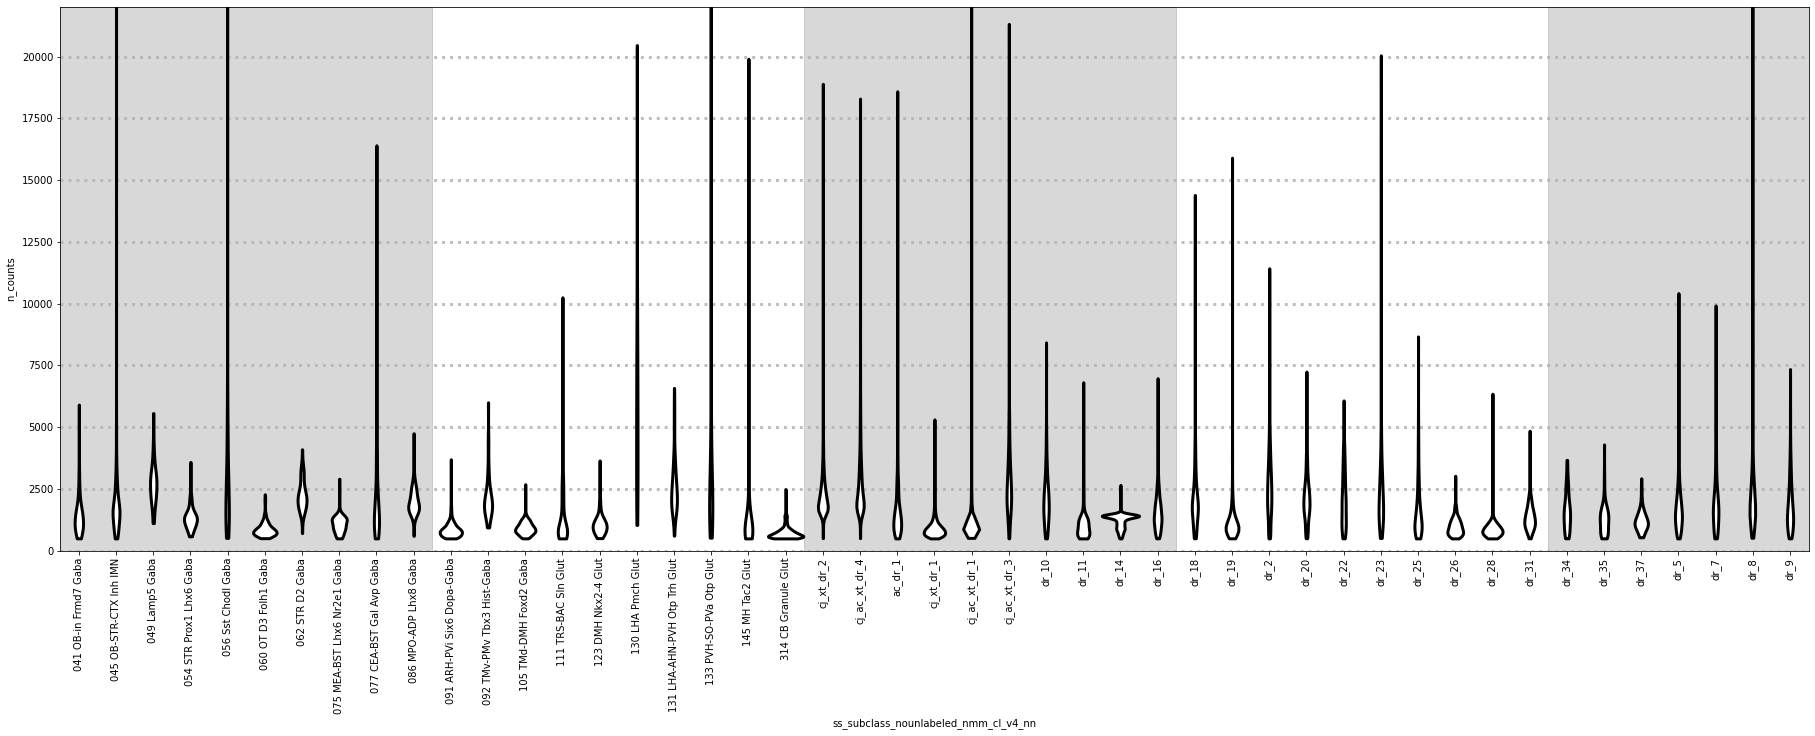

In [41]:
for ci, chunk in enumerate(order_one_chunks, start=1):
    plt.figure(figsize=(tile_width * len(chunk) / chunk_size, 10))
    ax = sns.violinplot(data = sam.adata.obs, x = level, y = 'n_counts', order = chunk,color = 'white',linewidth = 3,cut=0,inner=None,width = 1)

    n = len(chunk)

    # get y-limits AFTER plotting
    ymin, ymax = ax.get_ylim()

    # alternating background spans
    for start in range(0, n, 10):
        if (start // 10) % 2 == 0:
            ax.axvspan(
                start - 0.5,
                min(start + 10 - 0.5, n - 0.5),
                color="grey",
                alpha=0.3,
                zorder=0
            )

    # keep tight margins
    ax.set_xlim(-0.5, n - 0.5)

    # dotted horizontal lines at y ticks
    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=3,
        alpha=0.8
    )

    # make sure grid is behind violins but above background
    ax.set_axisbelow(True)

    #ax.set_xticklabels(renamed_order_one, fontsize = 6)
    plt.ylim(0,ncount_max)
    plt.xticks(rotation=90)
    for violin in ax.collections:
        violin.set_edgecolor("black")
    plt.savefig('Figures/Figures_07242026/' + org + '_ncounts_ct_tileone_' + str(ci) + '.pdf',bbox_inches ='tight')
    plt.show()

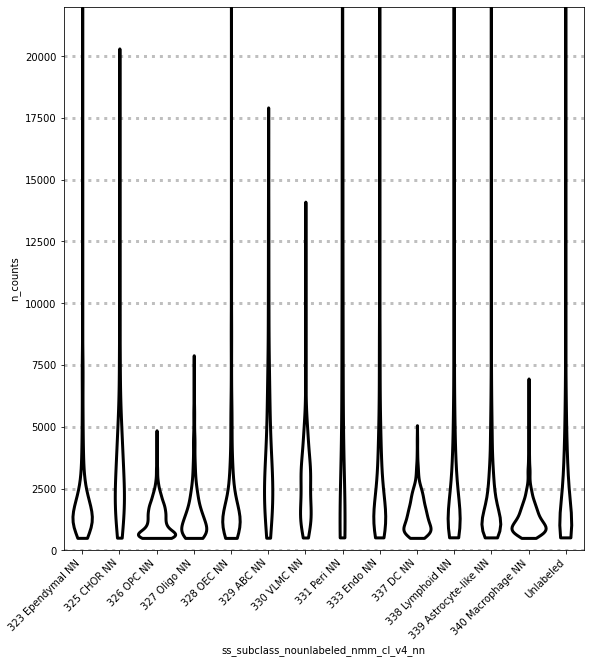

In [42]:
plt.figure(figsize=(40/frac,10))
ax = sns.violinplot(data = sam.adata.obs, x = level, y = 'n_counts', order = order_two,color = 'white',linewidth = 3,cut=0,inner=None,width = 1)

# dotted horizontal lines at y ticks
ax.yaxis.grid(
    True,
    linestyle=":",
    linewidth=3,
    alpha=0.8
)

# make sure grid is behind violins but above background
ax.set_axisbelow(True)

plt.ylim(0,ncount_max)
plt.xticks(rotation=45, ha = 'right')
for violin in ax.collections:
    violin.set_edgecolor("black")
plt.savefig('Figures/Figures_07242026/'+org+'_ncounts_ct_tiletwo.pdf')

In [43]:
sam.adata.obs['n_genes'].quantile(.999)

4252.142000000007

In [44]:
ngenes_max = 4300

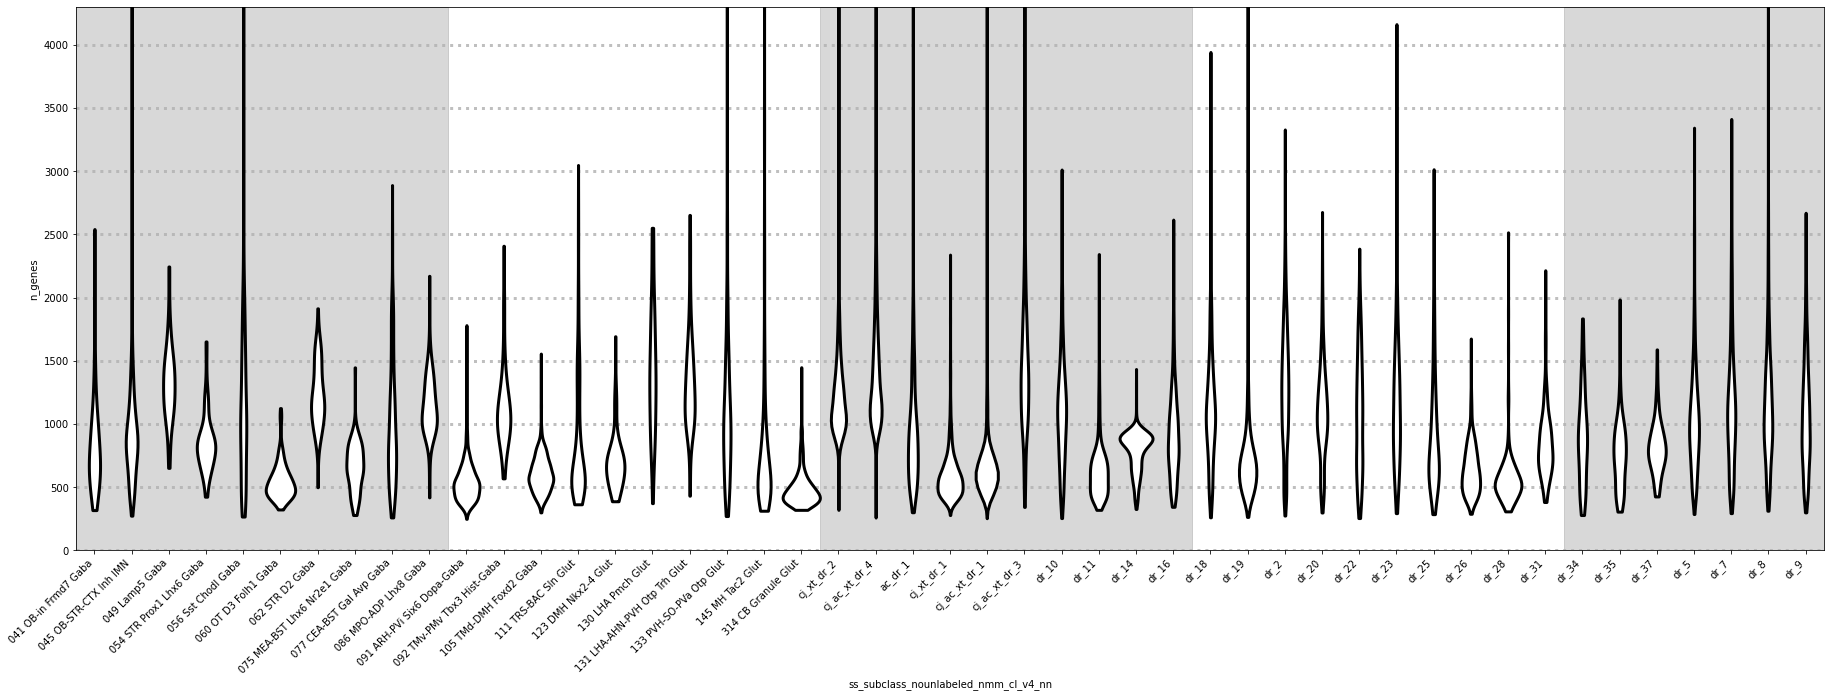

In [45]:
for ci, chunk in enumerate(order_one_chunks, start=1):
    plt.figure(figsize=(tile_width * len(chunk) / chunk_size, 10))
    ax = sns.violinplot(data = sam.adata.obs, x = level, y = 'n_genes', order = chunk, color = 'white',edgecolor='black',linewidth=3,inner = None,cut=0,width = 1)

    n = len(chunk)

    # get y-limits AFTER plotting
    ymin, ymax = ax.get_ylim()

    # alternating background spans
    for start in range(0, n, 10):
        if (start // 10) % 2 == 0:
            ax.axvspan(
                start - 0.5,
                min(start + 10 - 0.5, n - 0.5),
                color="grey",
                alpha=0.3,
                zorder=0
            )

    # dotted horizontal lines at y ticks
    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=3,
        alpha=0.8
    )

    # make sure grid is behind violins but above background
    ax.set_axisbelow(True)

    # keep tight margins
    ax.set_xlim(-0.5, n - 0.5)

    plt.ylim(0,ngenes_max)
    plt.xticks(rotation=45, ha = 'right')
    for violin in ax.collections:
        violin.set_edgecolor("black")
    plt.savefig('Figures/Figures_07242026/'+org+'_ngenes_ct_tileone_' + str(ci) + '.pdf',bbox_inches = 'tight')
    plt.show()

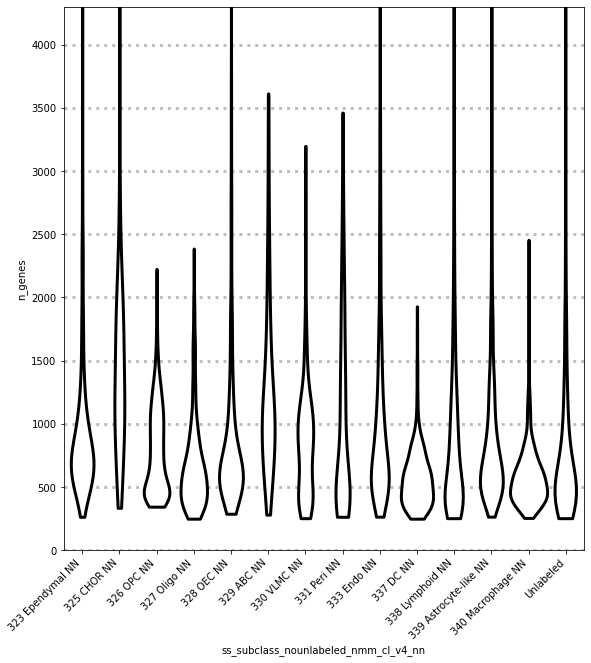

In [46]:
plt.figure(figsize=(40/frac,10))
ax = sns.violinplot(data = sam.adata.obs, x = level, y = 'n_genes', order = order_two, color = 'white',edgecolor='black',linewidth=3,inner = None,cut=0,width = 1)
        
# dotted horizontal lines at y ticks
ax.yaxis.grid(
    True,
    linestyle=":",
    linewidth=3,
    alpha=0.8
)

# make sure grid is behind violins but above background
ax.set_axisbelow(True)

plt.ylim(0,ngenes_max)
plt.xticks(rotation=45, ha = 'right')
for violin in ax.collections:
    violin.set_edgecolor("black")
plt.savefig('Figures/Figures_07242026/'+org+'_ngenes_ct_tiletwo.pdf')

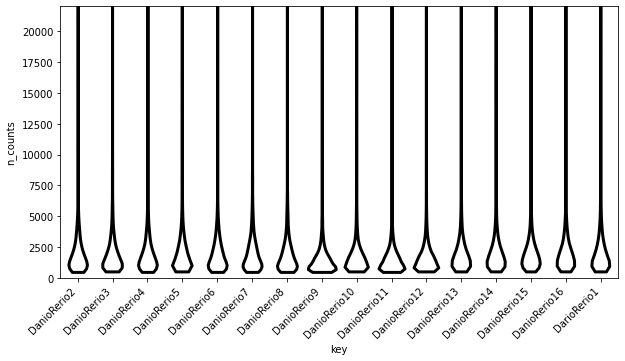

In [47]:
plt.figure(figsize=(10,5))
ax = sns.violinplot(data = sam.adata.obs, x = 'key', y = 'n_counts',color = 'white',cut=0,linewidth=3,inner=None)
plt.xticks(rotation=45, ha = 'right')
for violin in ax.collections:
    violin.set_edgecolor("black")
plt.ylim(0,ncount_max)
plt.savefig('Figures/Figures_07242026/'+org+'_ncounts_library.pdf',bbox_inches='tight')

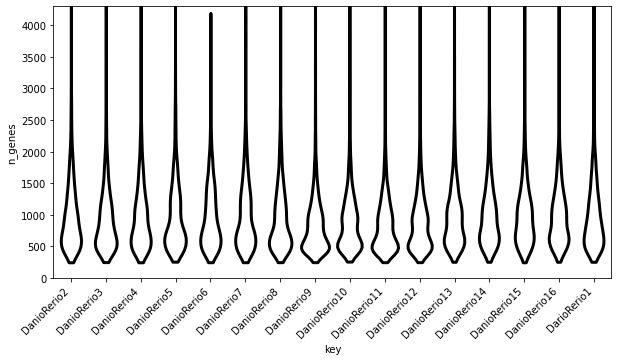

In [48]:
plt.figure(figsize=(10,5))
ax = sns.violinplot(data = sam.adata.obs, x = 'key', y = 'n_genes',color = 'white',cut=0,linewidth=3,inner=None)
plt.xticks(rotation=45, ha = 'right')
for violin in ax.collections:
    violin.set_edgecolor("black")
plt.ylim(0,ngenes_max)
plt.savefig('Figures/Figures_07242026/'+org+'_ngenes_library.pdf')